## Descriptive Statistics

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_04cleaned.csv"))
tox = df[df['at_risk'] == 1]
no_tox = df[df['at_risk'] == 0]

### Patient Counts and Descriptive Statistics

NHT Counts

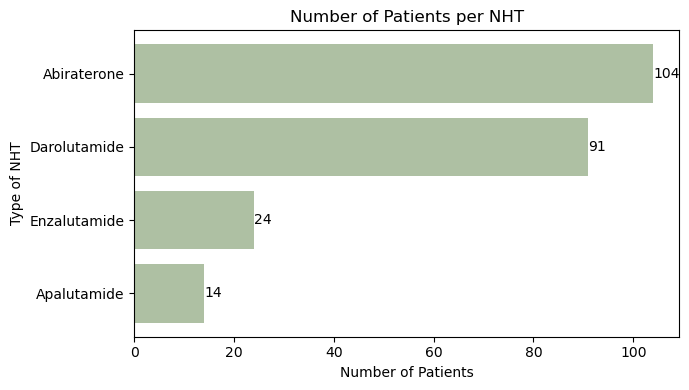

In [79]:
# Count unique patients per NHT
num_patients = df.groupby('specific_nht_used')['unique_patient_id'].nunique()

num_patients = num_patients.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

p=ax.barh(num_patients.index, num_patients.values,
          color='#aec0a3')
ax.bar_label(p, label_type='edge')
ax.set_ylabel('Type of NHT')
ax.set_xlabel('Number of Patients')
ax.set_title('Number of Patients per NHT')
plt.tight_layout()
plt.show()

ADT Counts

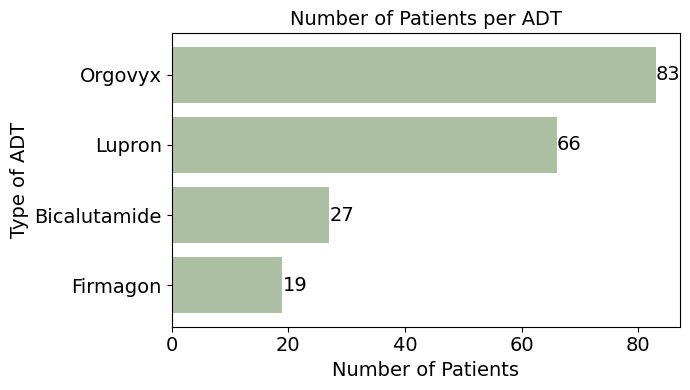

In [80]:
# Count unique patients per ADT
num_patients = df.groupby('adt_agent')['unique_patient_id'].nunique()

num_patients = num_patients.sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(7,4))

ax.barh(num_patients.index, num_patients.values)
p=ax.barh(num_patients.index, num_patients.values, color='#aec0a3')
ax.bar_label(p, label_type='edge', fontsize=14)
ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients per ADT', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

NHT and ADT Combinations

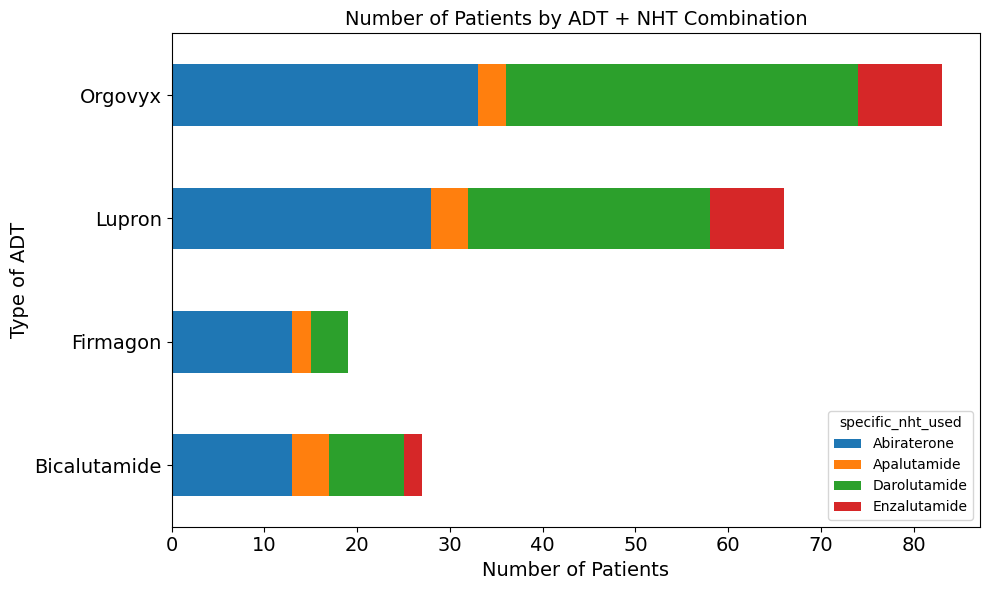

In [81]:
combo_counts = (
    df.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10,6))

combo_counts.plot(
    kind='barh',
    stacked=True,
    ax=ax
)

ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients by ADT + NHT Combination', fontsize=14)

ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

Descriptives of At Risk Patients

In [14]:
cont_vars = ['age','bmi','ascvd_10yr','sbp','dbp']

table1_cont = df.groupby('at_risk')[cont_vars].agg(['mean','std'])

print(table1_cont)

cat_vars = [
    'ethnicity','hx_smoking','hx_htn','hx_hld','hx_dm2',
    'hx_cad','hx_chf','hx_arrhythmia','hx_pad','hx_cva',
    'has_pcp','lipid_panel_checked','a1c_checked',
    'cards_prior','diet_counseling','exercise_counseling'
]

table1_cat = {}

for v in cat_vars:
    table1_cat[v] = pd.crosstab(df[v], df['at_risk'], normalize='columns') * 100

for k,v in table1_cat.items():
    print("\n",k)
    print(v)

               age                  bmi           ascvd_10yr            \
              mean       std       mean       std       mean       std   
at_risk                                                                  
0.0      71.766129  9.337492  27.801290  5.194846   1.774194  0.419809   
1.0      71.405063  8.460343  27.521266  5.080351   1.835443  0.373149   

                sbp                   dbp            
               mean        std       mean       std  
at_risk                                              
0.0      129.733871  13.662666  73.629032  7.867260  
1.0      130.759494  14.506599  73.392405  8.662353  

 ethnicity
at_risk          0.0        1.0
ethnicity                      
Asian      12.500000  15.189873
Black       6.666667  11.392405
Caucasian  59.166667  49.367089
Hispanic   12.500000   8.860759
Other       9.166667  15.189873

 hx_smoking
at_risk          0.0        1.0
hx_smoking                     
0           70.16129  56.962025
1           29

### Baseline Demographics
Age

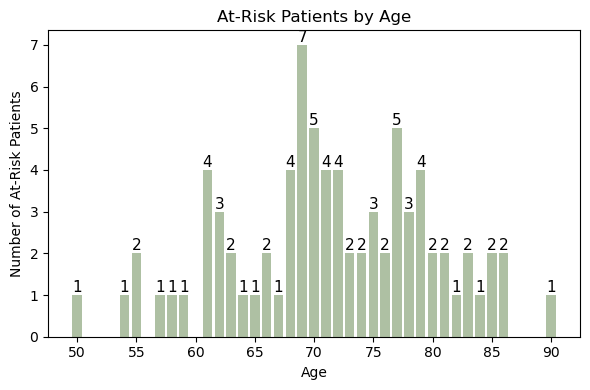

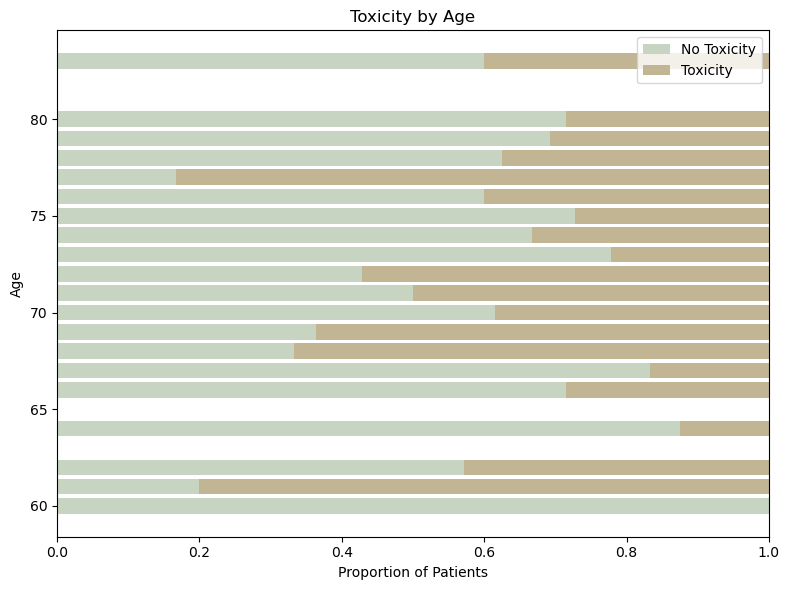

In [156]:
# Count unique at-risk patients by age
counts = (
    tox
    .groupby('age')['unique_patient_id']
    .nunique()
    .sort_index()
)

# Plot
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(counts.index, counts.values, color='#aec0a3')

ax.bar_label(bars, fontsize=11)

ax.set_xlabel('Age')
ax.set_ylabel('Number of At-Risk Patients')
ax.set_title('At-Risk Patients by Age')

plt.tight_layout()
plt.show()

counts = (
    df.groupby(['age', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts[counts.sum(axis=1) >= 5]

fig, ax = plt.subplots(figsize=(8,6))
props = counts.div(counts.sum(axis=1), axis=0)
ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Age')
ax.set_title('Toxicity by Age')
ax.legend()

plt.tight_layout()
plt.show()

Ethnicity

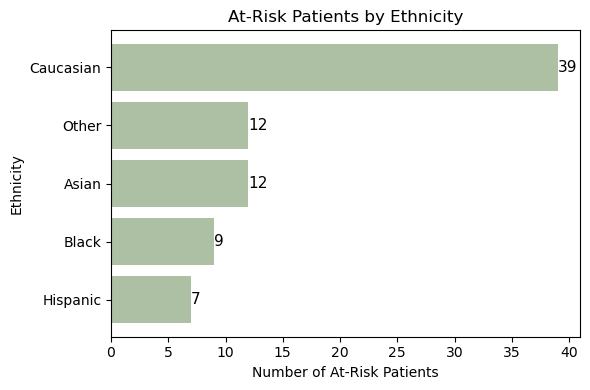

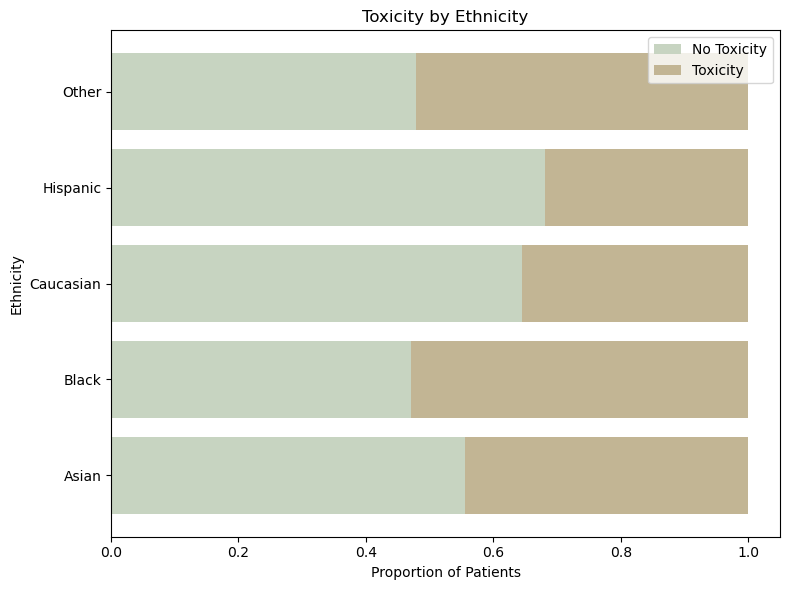

In [4]:
counts = (
    tox
    .groupby('ethnicity')['unique_patient_id']
    .nunique()
    .sort_values(ascending=True)
)

# Plot
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.barh(counts.index, counts.values, color='#aec0a3')

ax.bar_label(bars, fontsize=11)

ax.set_xlabel('Number of At-Risk Patients')
ax.set_ylabel('Ethnicity')
ax.set_title('At-Risk Patients by Ethnicity')

plt.tight_layout()
plt.show()

counts = (
    df.groupby(['ethnicity', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts[counts.sum(axis=1) >= 5]

fig, ax = plt.subplots(figsize=(8,6))
props = counts.div(counts.sum(axis=1), axis=0)
ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Ethnicity')
ax.set_title('Toxicity by Ethnicity')
ax.legend()

plt.tight_layout()
plt.show()

BMI

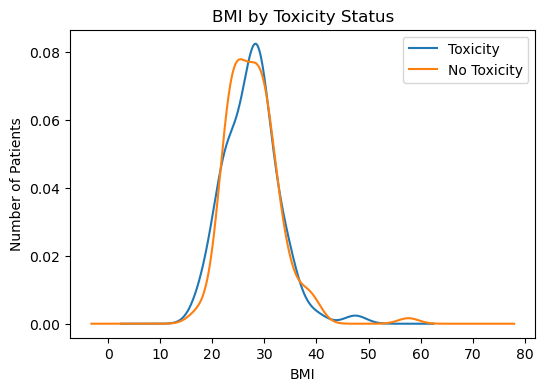

In [45]:
tox_bmi = df[df['at_risk'] == 1]['bmi']
no_tox_bmi = df[df['at_risk'] == 0]['bmi']

tox_bmi.dropna().plot(kind='density', figsize=(6,4), label='Toxicity')
no_tox_bmi.dropna().plot(kind='density', figsize=(6,4), label='No Toxicity')

plt.xlabel('BMI')
plt.ylabel('Number of Patients')
plt.title('BMI by Toxicity Status')
plt.legend()

plt.show()

Proportion of Patients in Toxicity Group that had Baseline Disease

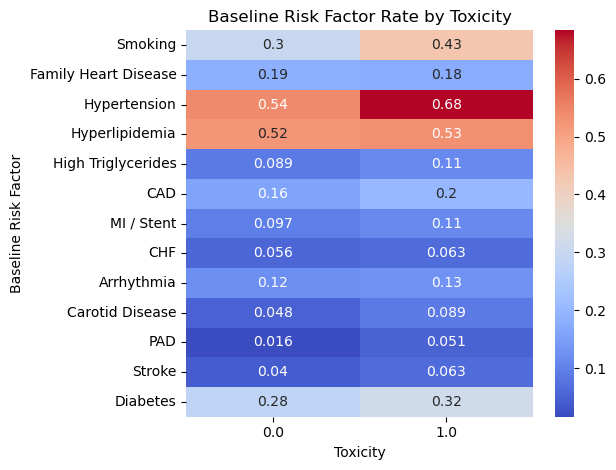

In [117]:
risk_vars = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 
             'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

heat = df.groupby('at_risk')[risk_vars].mean().T
heat.index = heat.index.map(condition_names)

sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.title("Baseline Risk Factor Rate by Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Baseline Risk Factor")
plt.tight_layout()

Proportion of Patients with Baseline Disease that Developed Toxicity

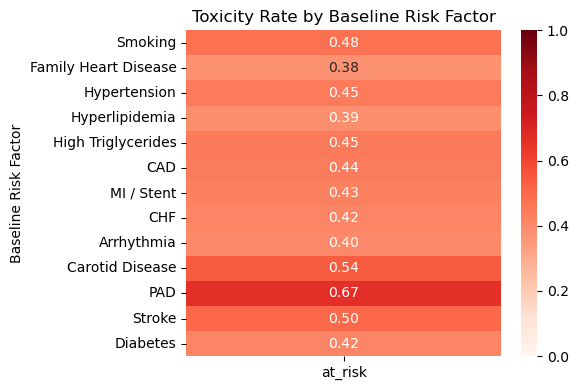

In [116]:
heatmap_data = []

health_cols = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

#affected if hx_smoking = 1 or 2, family_hx_hd = 1, hx_htn=1, hx_hld=1, hx_high_tg=1, hx_cad =1, hx_mi_stent=1, hx_chf=1, hx_arrhythmia=1, hx_carotid=1, hx_pad=1, hx_cva=1, hx_dm2=1

condition_filter = {
    "hx_smoking": lambda x: x >= 1,
    "family_hx_hd": lambda x: x == 1,
    'hx_htn': lambda x: x == 1,
    'hx_hld': lambda x: x == 1,
    'hx_high_tg': lambda x: x == 1,
    'hx_cad': lambda x: x == 1,
    'hx_mi_stent': lambda x: x == 1,
    'hx_chf': lambda x: x == 1,
    'hx_arrhythmia': lambda x: x == 1,
    'hx_carotid': lambda x: x == 1,
    'hx_pad': lambda x: x == 1,
    'hx_cva': lambda x: x == 1,
    'hx_dm2': lambda x: x == 1
}

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

for col in health_cols:
    subset = df[condition_filter[col](df[col])]
    
    tox_value = subset['at_risk'].mean()
     
    heatmap_data.append({
        "condition": col,
        "at_risk": tox_value
    })

heatmap_df = pd.DataFrame(heatmap_data).set_index("condition")
heatmap_df.index = heatmap_df.index.map(condition_names)

plt.figure(figsize=(6,4))

ax=sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=1,
    fmt=".2f"
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Toxicity Rate by Baseline Risk Factor")
plt.xlabel("")
plt.ylabel("Baseline Risk Factor")

plt.tight_layout()
plt.show()

Toxicity by NHT

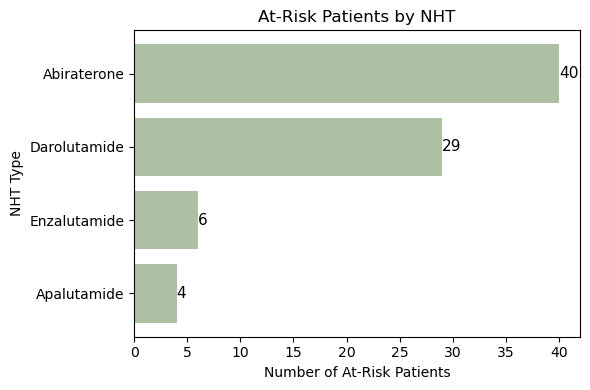

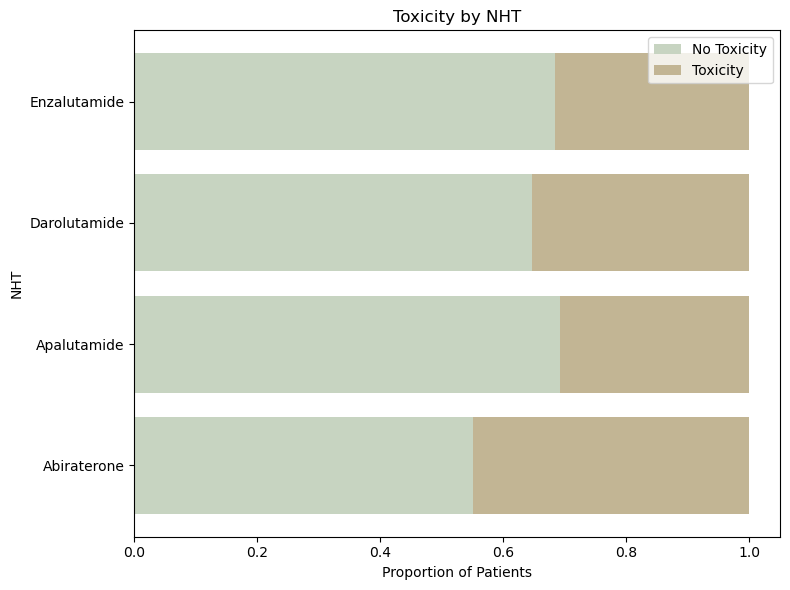

In [5]:
counts = (
    tox
    .groupby('specific_nht_used')['unique_patient_id']
    .nunique()
    .sort_values(ascending=True)
)

# Plot
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.barh(counts.index, counts.values, color='#aec0a3')

ax.bar_label(bars, fontsize=11)

ax.set_xlabel('Number of At-Risk Patients')
ax.set_ylabel('NHT Type')
ax.set_title('At-Risk Patients by NHT')

plt.tight_layout()
plt.show()

counts = (
    df.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(8,6))
props = counts.div(counts.sum(axis=1), axis=0)
ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('NHT')
ax.set_title('Toxicity by NHT')
ax.legend()

plt.tight_layout()
plt.show()

Toxicity by ADT

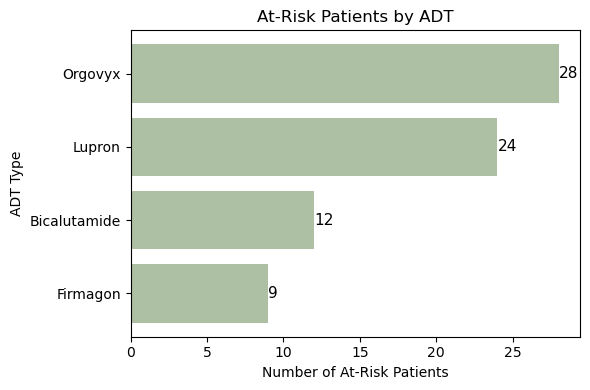

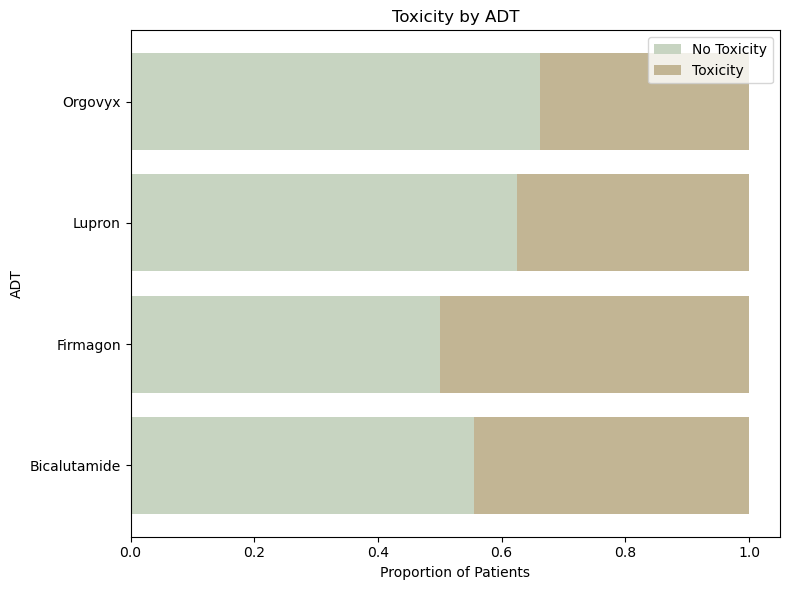

In [6]:
counts = (
    tox
    .groupby('adt_agent')['unique_patient_id']
    .nunique()
    .sort_values(ascending=True)
)

# Plot
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.barh(counts.index, counts.values, color='#aec0a3')

ax.bar_label(bars, fontsize=11)

ax.set_xlabel('Number of At-Risk Patients')
ax.set_ylabel('ADT Type')
ax.set_title('At-Risk Patients by ADT')

plt.tight_layout()
plt.show()

counts = (
    df.groupby(['adt_agent', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(8,6))
props = counts.div(counts.sum(axis=1), axis=0)
ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('ADT')
ax.set_title('Toxicity by ADT')
ax.legend()

plt.tight_layout()
plt.show()

### Time Period Length Between ADT and NHT Start

Overall

In [ ]:
df['days_adt_to_nht'].describe()

count      192.000000
mean       509.213542
std       3146.876234
min       -731.000000
25%          0.000000
50%         28.000000
75%        184.750000
max      42759.000000
Name: days_adt_to_nht, dtype: float64

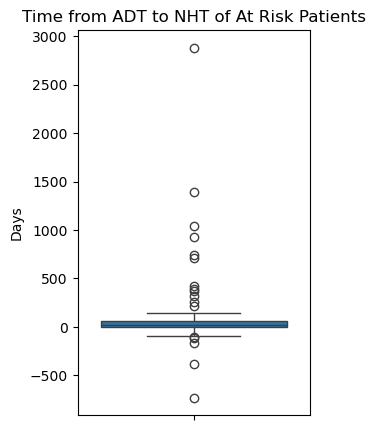

In [83]:
plt.figure(figsize=(3,5))
sns.boxplot(data=tox, y='days_adt_to_nht')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients")
plt.ylabel("Days")
plt.show()

Split by NHTs

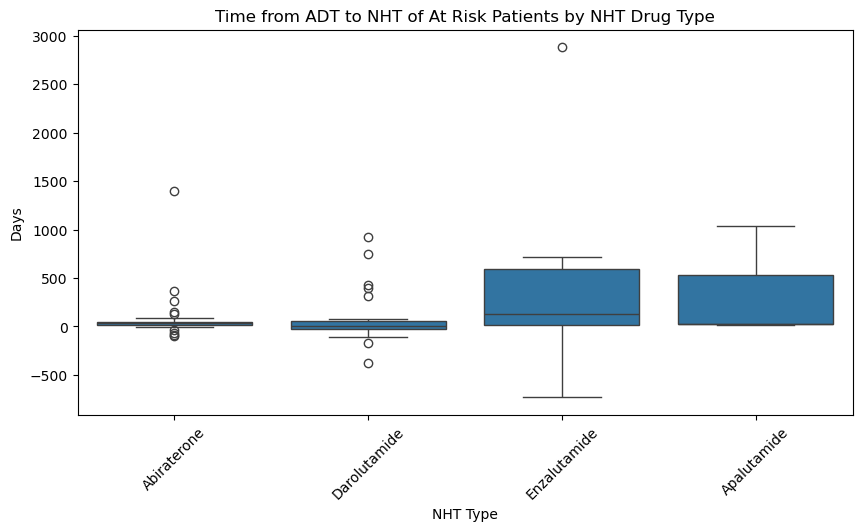

In [50]:
plt.figure(figsize=(10,5))
sns.boxplot(data=tox, x='specific_nht_used', y='days_adt_to_nht')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients by NHT Drug Type")
plt.xlabel("NHT Type")
plt.ylabel("Days")
plt.show()

Split by ADTs

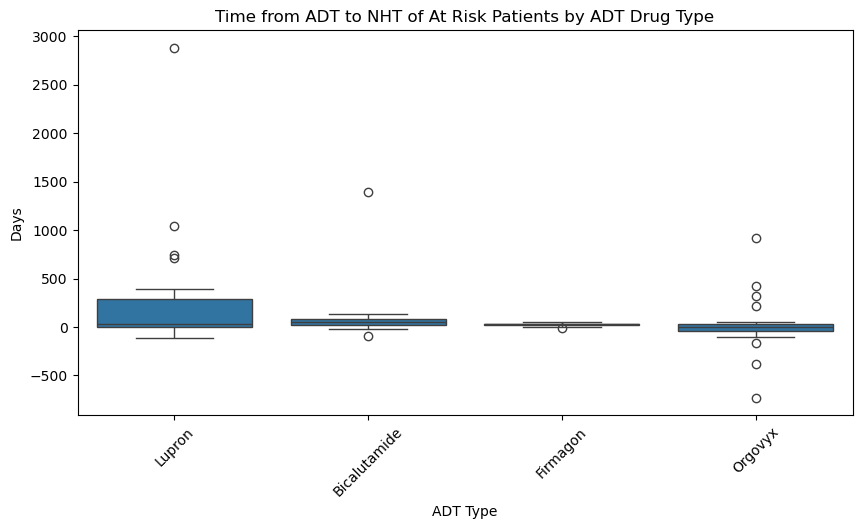

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(data=tox, x='adt_agent', y='days_adt_to_nht')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients by ADT Drug Type")
plt.xlabel("ADT Type")
plt.ylabel("Days")
plt.show()

### Cardiology Intervention

Proportion of Patients Receiving Intervention, given Baseline Risk Factor

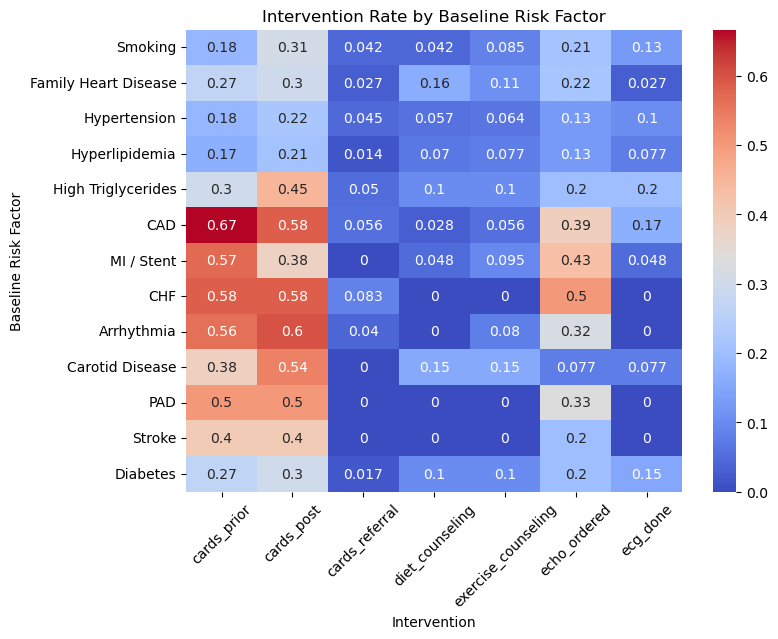

In [115]:
risk_factors = ['hx_smoking', 'family_hx_hd', 'hx_htn','hx_hld','hx_high_tg', 'hx_cad','hx_mi_stent',
                'hx_chf','hx_arrhythmia','hx_carotid','hx_pad','hx_cva','hx_dm2']
interventions = ['cards_prior', 'cards_post', 'cards_referral', 'diet_counseling','exercise_counseling','echo_ordered', 'ecg_done']

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

heat = pd.DataFrame(index=risk_factors, columns=interventions)

for r in risk_factors:
    for i in interventions:
        heat.loc[r,i] = df[df[r]==1][i].mean()

heat = heat.astype(float)
heat.index = heat.index.map(condition_names)

plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.xticks(rotation=45)
plt.title("Intervention Rate by Baseline Risk Factor")
plt.xlabel("Intervention")
plt.ylabel("Baseline Risk Factor")
plt.show()

Cardiologist Visits of At Risk Patients

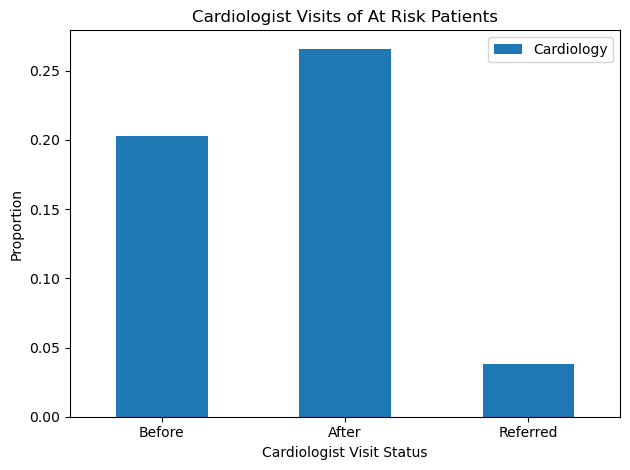

In [119]:
care = pd.DataFrame({
    "Before": tox['cards_prior'].mean(),
    "After": tox['cards_post'].mean(),
    "Referred": tox['cards_referral'].mean()
}, index=["Cardiology"])

care.T.plot(kind='bar')
plt.title("Cardiologist Visits of At Risk Patients")
plt.xticks(rotation=0)
plt.xlabel("Cardiologist Visit Status")
plt.ylabel("Proportion")
plt.tight_layout()

Preventative Care of At Risk Patients

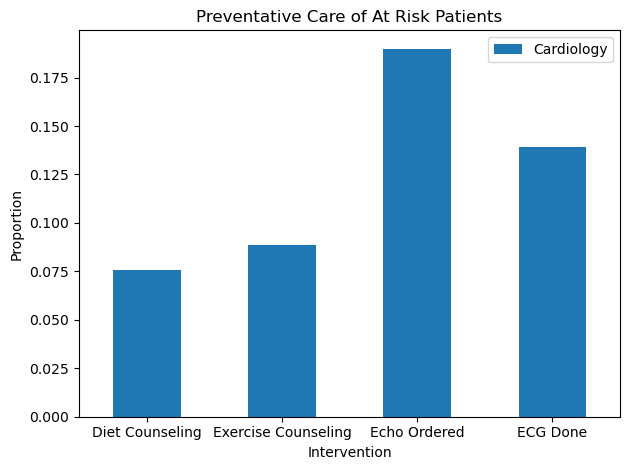

In [120]:
care = pd.DataFrame({
    "Diet Counseling": tox['diet_counseling'].mean(),
    "Exercise Counseling": tox['exercise_counseling'].mean(),
    "Echo Ordered": tox['echo_ordered'].mean(),
    "ECG Done": tox['ecg_done'].mean()
}, index=["Cardiology"])

care.T.plot(kind='bar')
plt.title("Preventative Care of At Risk Patients")
plt.xticks(rotation=0)
plt.xlabel("Intervention")
plt.ylabel("Proportion")
plt.tight_layout()

### Medication History

BP Treatment Pre-NHT

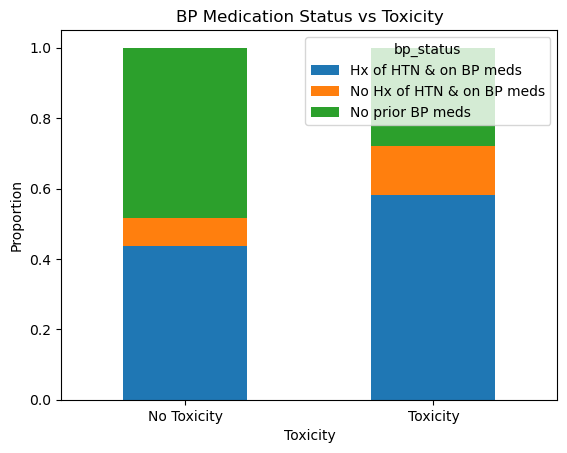

In [143]:
df['bp_status'] = np.select(
    [
        (df['hx_htn']==1) & (df['bp_meds_prior']==1),
        (df['hx_htn']==0) & (df['bp_meds_prior']==1),
        (df['bp_meds_prior']==0)
    ],
    [
        'Hx of HTN & on BP meds',
        'No Hx of HTN & on BP meds',
        'No prior BP meds'
    ],
    default='Other'
)

bp_plot = pd.crosstab(df['bp_status'], df['at_risk'], normalize='columns')

ax = bp_plot.T.plot(kind='bar', stacked=True)
plt.title("BP Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()

Diabetes Treatment Pre-NHT

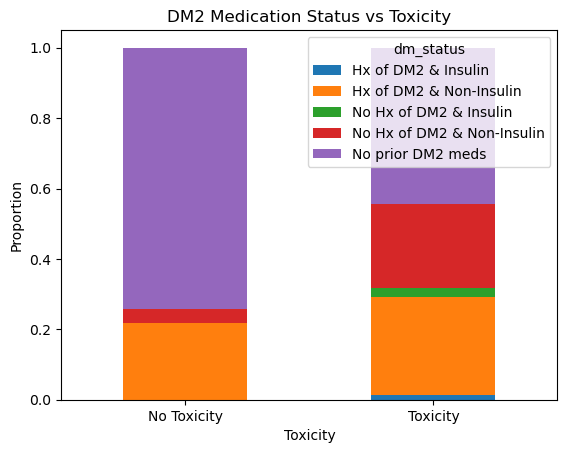

In [137]:
df['dm_status'] = np.select(
    [
        (df['hx_dm2']==1) & (df['dm_noninsulin']==1),
        (df['hx_dm2']==1) & (df['on_insulin']==1),
        (df['hx_dm2']==0) & (df['dm_noninsulin']==1),
        (df['hx_dm2']==0) & (df['on_insulin']==1),
        (df['dm_noninsulin']==0) & (df['on_insulin']==0)
    ],
    [
        'Hx of DM2 & Non-Insulin',
        'Hx of DM2 & Insulin',
        'No Hx of DM2 & Non-Insulin',
        'No Hx of DM2 & Insulin',
        'No prior DM2 meds'
    ],
    default='Other'
)

bp_plot = pd.crosstab(df['dm_status'], df['at_risk'], normalize='columns')

ax = bp_plot.T.plot(kind='bar', stacked=True)
plt.title("DM2 Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()

HLD Treatment Pre-NHT

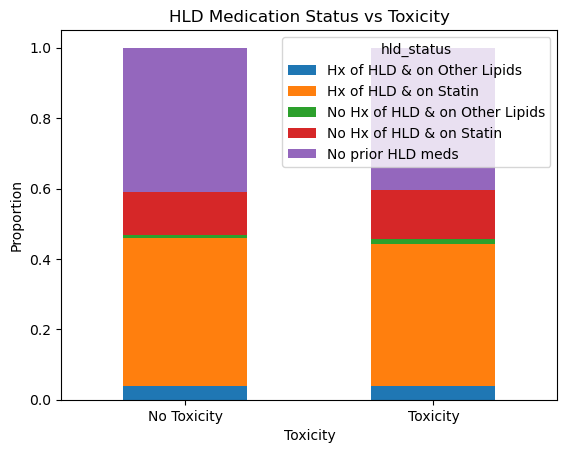

In [142]:
df['hld_status'] = np.select(
    [
        (df['hx_hld']==1) & (df['statin_prior']==1),
        (df['hx_hld']==1) & (df['other_lipid_prior']==1),
        (df['hx_hld']==0) & (df['statin_prior']==1),
        (df['hx_hld']==0) & (df['other_lipid_prior']==1),
        (df['statin_prior']==0) & (df['other_lipid_prior']==0)
    ],
    [
    'Hx of HLD & on Statin',
    'Hx of HLD & on Other Lipids',
    'No Hx of HLD & on Statin',
    'No Hx of HLD & on Other Lipids',
    'No prior HLD meds'
    ],
    default='Other'
)

statin_plot = pd.crosstab(df['hld_status'], df['at_risk'], normalize='columns')

ax = statin_plot.T.plot(kind='bar', stacked=True)
plt.title("HLD Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()